In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

In [3]:
import numpy as np

# Read the data from text file
Sat = np.loadtxt('R134a_PressureTable.txt')

# Extract and convert columns
P = Sat[:, 0] * 1e6          # [Pa]
T = Sat[:, 1] + 273.15       # [K]
vf = Sat[:, 2]               # [m^3/kg]
vg = Sat[:, 3]               # [m^3/kg]
uf = Sat[:, 4] * 1e3         # [J/kg]
ug = Sat[:, 5] * 1e3         # [J/kg]
hf = Sat[:, 6] * 1e3         # [J/kg]
hg = Sat[:, 7] * 1e3         # [J/kg]
sf = Sat[:, 8] * 1e3         # [J/(kg·K)]
sg = Sat[:, 9] * 1e3         # [J/(kg·K)]


In [4]:
# Load comma-separated values (CSV) and skip headers if present
Asup = np.genfromtxt('R134a_SuperHeated01_test02.txt', delimiter=',', skip_header=0)

# Extract and convert columns
Pgs = Asup[:, 0] * 1e6         # [Pa]
Tgs = Asup[:, 1] + 273.15      # [K]
vgs = Asup[:, 2]               # [m^3/kg]
ugs = Asup[:, 3] * 1e3         # [J/kg]
hgs = Asup[:, 4] * 1e3         # [J/kg]
sgs = Asup[:, 5] * 1e3         # [J/(kg·K)]


In [64]:
sgs

array([ 952. , 1006.2, 1037.1, 1067.5, 1097.3, 1126.7, 1155.7, 1184.4,
       1212.6, 1240.5, 1268.1, 1295.4, 1322.4,  939.5,  960.2,  991.8,
       1022.7, 1053.1, 1082.9, 1112.2, 1141.1, 1169.6, 1197.7, 1225.4,
       1252.8, 1279.9,  932.2,  960.6,  992.2, 1023. , 1053.2, 1082.8,
       1112. , 1140.7, 1169. , 1196.9, 1224.4, 1251.6, 1278.5,  927.3,
        936.2,  968.4,  999.8, 1030.4, 1060.4, 1089.8, 1118.7, 1147.2,
       1175.3, 1203. , 1230.3, 1257.3,  925.3,  925.6,  958.2,  989.8,
       1020.6, 1050.8, 1080.4, 1109.4, 1138. , 1166.1, 1193.9, 1221.2,
       1248.3,  922.2,  939.9,  972.1, 1003.4, 1033.9, 1063.7, 1093. ,
       1121.8, 1150.1, 1178. , 1205.5, 1232.6,  919.7,  923.8,  956.6,
        988.3, 1019.2, 1049.4, 1078.9, 1107.9, 1136.4, 1164.4, 1192. ,
       1219.3, 1246.1, 1272.7,  917.7,  942.7,  974.9, 1006.2, 1036.7,
       1066.5, 1095.7, 1124.3, 1152.5, 1180.2, 1107.6, 1234.5, 1261.1,
        914.5,  918.2,  951.5,  983.7, 1014.8, 1045.2, 1074.8, 1103.8,
      

In [6]:
Tgs.shape

(258,)

In [7]:
h_interp = interp1d(T,hg)
h2 = h_interp(-8+273.15)
h2

array(242535.40254237)

In [8]:
s_interp = interp1d(T,sg)
s2 = s_interp(-8+273.15)
s2

array(923.92733051)

In [9]:
h4 = hf[np.where(P==0.8*10**6)]
h4

array([93420.])

In [10]:
h1 = h4
h1

array([93420.])

In [11]:
h3 = hgs[np.where(Pgs==0.8*10**6)]
h3

array([264150., 273660., 284390., 294980., 305500., 316000., 326520.,
       337080., 347710., 358400., 369190., 380070., 391050., 402140.,
       413330., 424630.])

In [12]:
from scipy.interpolate import griddata
import numpy as np

# Assume Pgs, sgs, hgs are 1D arrays (flattened if from a meshgrid)

# Stack the input coordinates: (Pressure, Entropy)
points = np.column_stack((Pgs, sgs))

# hgs is the corresponding value at each (P, s)
values = hgs

# Point where you want to interpolate
P3 = 0.8*10**6  # example [Pa]
  # example [J/(kg·K)]
s2 = s2
# Interpolate h at (P3, s2)
h3 = griddata(points, values, (P3, s2), method='linear')
h3


array(269500.09458232)

In [13]:
# 1
def model(T2,P4,mdot):

    h_interp = interp1d(T,hg)
    h2 = h_interp(T2)
   

    s_interp = interp1d(T,sg)
    s2 = s_interp(T2)
    

    s3 = s2
    
    #T_interp = interp1d(Tgs,sgs)
    #T3 = T_interp()

    h4 = hf[np.where(P==P4)]
   

    h1 = h4

    points = np.column_stack((Pgs, sgs))
    values = hgs
    h3 = griddata(points, values, (P4, s2), method='linear')
    

    Wc = mdot*(h3-h2)
    Qh = mdot*(h3-h4)
    COP = Qh/Wc

    return Qh, Wc, COP

# how accurate should it be? in part 1 when finding h2 it is more convenient to use temperature saturation table. Is it fine to interpolate?

In [14]:
model(-8+273.15,0.8*10**6,0.1)[1]

2696.4692039951624

In [15]:
np.round(23.2323)

23.0

In [16]:
s3 = 923.23
s2 = s3

In [17]:
T_interp = interp1d(sgs[Pgs==800000],Tgs[Pgs==800000])
T3 = T_interp(923.93)
T3

array(309.35828247)

In [18]:
T3b = T[np.where(P==800000)]
s3b = sg[np.where(P==800000)]

In [19]:
T4 = T3b
s4 = sf[np.where(P==800000)]

In [20]:
h2f_inter = interp1d(T,hf)
h2f = h2f_inter(-8+273.15)
h2f

array(39545.48728814)

In [21]:
h2g_inter = interp1d(T,hg)
h2g = h2g_inter(-8+273.15)
h2g

array(242535.40254237)

In [22]:
x = (93420 - h2f) / (h2g - h2f)
s1f_inter = interp1d(T,sf)
s1f = s1f_inter(-8+273.15)
s1f

array(158.24004237)

In [23]:
s1g_inter = interp1d(T,sg)
s1g = s1g_inter(-8+273.15)
s1g

array(923.92733051)

In [24]:
s1 = x*s1g+(1-x)*s1f

In [25]:
s4/1000-s1/1000

array([-0.01555718])

In [26]:
s3b

array([906.6])

In [27]:
ss = np.array([s3,s3b[0],s4[0],s1,s2,s3])/1000
ss

array([0.92323   , 0.9066    , 0.3459    , 0.36145718, 0.92323   ,
       0.92323   ])

In [28]:
Ts = np.array([T3,T3b[0],T4[0],-8+273.15,-8+273.15,T3])

In [29]:
T4

array([304.48])

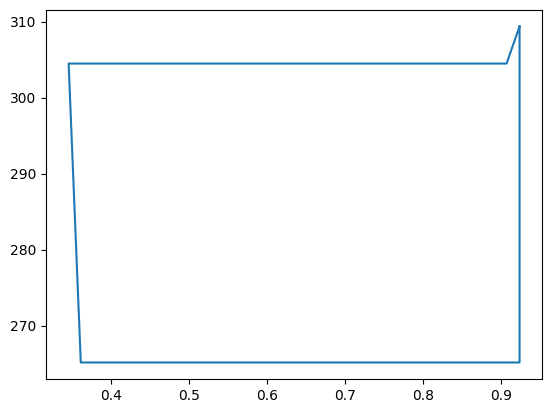

In [30]:
plt.plot(ss,Ts)

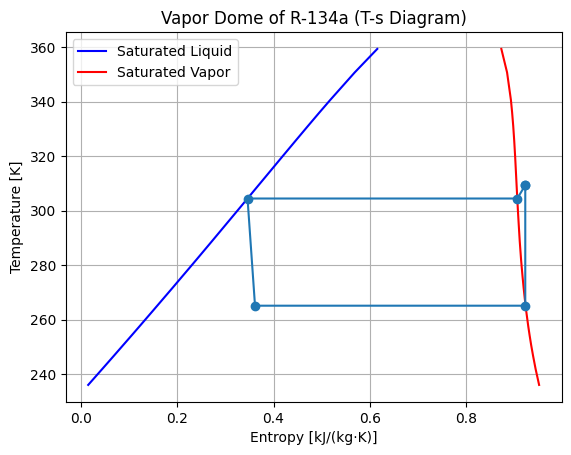

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Example: use your preprocessed data
# T: temperature in K
# sf, sg: entropy values [J/(kg·K)]

# Plot saturated liquid and vapor lines
plt.plot(sf / 1e3, T, label='Saturated Liquid', color='blue')
plt.plot(sg / 1e3, T, label='Saturated Vapor', color='red')

plt.xlabel('Entropy [kJ/(kg·K)]')
plt.ylabel('Temperature [K]')
plt.title('Vapor Dome of R-134a (T-s Diagram)')

#plt.plot(s3/1000,T3,marker='o')
#plt.scatter(s3b/1000,T3b,color='blue')
#plt.scatter(s4/1000,T4,color='green')
#plt.scatter(s1/1000,-8+273.15)
#plt.scatter(s2/1000,-8+273.15)
plt.plot(ss,Ts,marker='o')
#plt.xlim(0.2,1)
#plt.ylim(260,320)

plt.legend()
plt.grid(True)
plt.show()



In [32]:
T-273.15

array([-37.07, -31.21, -26.43, -22.36, -18.8 , -15.62, -12.73, -10.09,
        -5.37,  -1.23,   2.48,   5.84,   8.93,  15.74,  21.58,  26.72,
        31.33,  35.53,  39.39,  46.32,  52.43,  57.92,  62.91,  67.49,
        77.59,  86.22])

In [33]:
# 2

def model2(T2,T4,mdot):

    T2 += 273.15
    T4 += 273.15

    P4_interp = interp1d(T,P)
    P4 = P4_interp(T4)

    h_interp = interp1d(T,hg)
    h2 = h_interp(T2)
    h2 = np.round(h2,2)

    s_interp = interp1d(T,sg)
    s2 = s_interp(T2)
    s2 = np.round(s2,2)

    s3 = s2
    
    #T_interp = interp1d(Tgs,sgs)
    #T3 = T_interp()

    h4_interp = interp1d(P,hf)
    h4 = h4_interp(P4)

    h4 = np.round(h4,2)

    h1 = h4

    points = np.column_stack((Pgs, sgs))
    values = hgs
    h3 = griddata(points, values, (P4, s2), method='linear')

    qc = h2-h1
    qh = h3-h4

    Wc = mdot*(h3-h2)
    Qh = mdot*(h3-h4)
    COP = Qh/Wc

    return Qh, Wc, COP, qc, qh

Text(0, 0.5, 'COP')

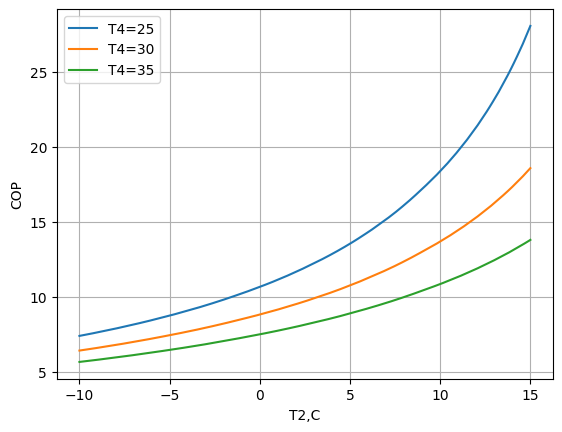

In [34]:
bT2 = np.linspace(-10,15,300)
bT4 = np.array([25,30,35])

COPs = np.zeros([300,3])
for i in range(len(bT4)):
    for j in range(len(bT2)):
        COP1 = model2(bT2[j],bT4[i],0.1)[2]
        COPs[j,i] = COP1
        
plt.plot(bT2,COPs[:,0],label='T4=25')
plt.plot(bT2,COPs[:,1],label='T4=30')
plt.plot(bT2,COPs[:,2],label='T4=35')
plt.legend()
plt.grid()
plt.xlabel('T2,C')
plt.ylabel('COP')

In [35]:
# 3
k = 398
L = 1
r1 = 3
r2 = 5
G = 2*np.pi*k*L/np.log(r2/r1)

In [36]:
# 4
qc, qh = model2(5,35,_)[3],model2(5,35,_)[4]
mdotc = G*5/qc
mdotc


TypeError: unsupported operand type(s) for *: 'Text' and 'float'

In [65]:
# 4

def model2_1(Tc,Th,T2,T4,mdot=None):

    Tc += 273.15
    Th += 273.15
    T2 += 273.15
    T4 += 273.15

    P4_interp = interp1d(T,P)
    P4 = P4_interp(T4)

    h_interp = interp1d(T,hg)
    h2 = h_interp(T2)
    h2 = np.round(h2,2)

    s_interp = interp1d(T,sg)
    s2 = s_interp(T2)
    s2 = np.round(s2,2)

    s3 = s2
    
    #T_interp = interp1d(Tgs,sgs)
    #T3 = T_interp()

    h4_interp = interp1d(P,hf)
    h4 = h4_interp(P4)

    h1 = h4

    points = np.column_stack((Pgs, sgs))
    values = hgs
    h3 = griddata(points, values, (P4, s2), method='linear')

    qc = h2-h1
    qh = h3-h4

    mdotc = np.max([G*(Tc-T2)/(h2-h1),0])
    mdoth = np.max([G*(T4-Th)/(h3-h4),0])
    mdot = np.min([mdoth,mdotc])

    Wc = mdot*(h3-h2)
    Qc = mdot*qc
    Qh = mdot*qh
    COP = Qh/Wc

    return Qh, Wc, COP, qc, qh


In [39]:
np.min([0.16,0.37])

0.16

In [40]:
model2_1(Tc=10,Th=22,T2=13,T4=35)[-1]

C:\Users\vadim\AppData\Local\Temp\ipykernel_19088\913973568.py:45: RuntimeWarning: invalid value encountered in scalar divide
  COP = Qh/Wc


169402.59114811564

C:\Users\vadim\AppData\Local\Temp\ipykernel_19088\39533921.py:45: RuntimeWarning: invalid value encountered in scalar divide
  COP = Qh/Wc


Text(0, 0.5, 'Qh')

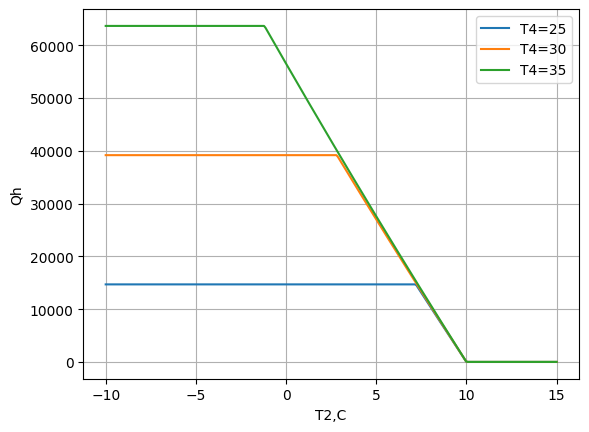

In [66]:

eT2 = np.linspace(-10,15,300)
eT4 = np.array([25,30,35])

Qhs = np.zeros([300,3])
for i in range(len(eT4)):
    for j in range(len(eT2)):
        Qh1 = model2_1(Tc=10,Th=22,T2=eT2[j],T4=eT4[i])[0]
        Qhs[j,i] = Qh1
        
plt.plot(eT2,Qhs[:,0],label='T4=25')
plt.plot(eT2,Qhs[:,1],label='T4=30')
plt.plot(eT2,Qhs[:,2],label='T4=35')
plt.legend()
plt.grid()
plt.xlabel('T2,C')
plt.ylabel('Qh')


In [42]:
Qhs[:,2][np.argmin(np.abs(bT2))]/1000

56.304563547166715

In [43]:
# 5 
qh5 = model2_1(10,22,5,35)[-1]
qh5

170519.2353198948

In [44]:
8180/qh5

0.04797112762471803

In [45]:
# 6
def model6(Tc,Th,T2,T4,mdot=None,Qh = 8180):

    Tc += 273.15
    Th += 273.15
    T2 += 273.15
    T4 += 273.15

    P4_interp = interp1d(T,P)
    P4 = P4_interp(T4)

    h_interp = interp1d(T,hg)
    h2 = h_interp(T2)
    h2 = np.round(h2,2)

    s_interp = interp1d(T,sg)
    s2 = s_interp(T2)
    s2 = np.round(s2,2)

    s3 = s2
    
    #T_interp = interp1d(Tgs,sgs)
    #T3 = T_interp()

    h4_interp = interp1d(P,hf)
    h4 = h4_interp(P4)

    h1 = h4

    points = np.column_stack((Pgs, sgs))
    values = hgs
    h3 = griddata(points, values, (P4, s2), method='linear')

    qc = h2-h1
    qh = h3-h4

    mdotc = np.max([G*(Tc-T2)/qc,0])
    mdoth = np.max([G*(T4-Th)/qh,0])
    mmax = np.min([mdoth,mdotc])

    actual_m = Qh/qh

    ratio = actual_m/mmax

    Wc = actual_m*(h3-h2)
    COP = qh/(h3-h2)


    return Qh, Wc, COP, qc, qh, ratio

In [46]:
Wc_for_smaller = []
Temps_for_smaller = []
Wc_for_bigger = []
Temps_for_bigger = []
T2s = np.linspace(-10,35,300)

for temp in T2s:
    work, ratio = model6(10,22,temp,35)[1], model6(10,22,temp,35)[-1]
    if ratio < 1:
        Wc_for_smaller.append(work)
        Temps_for_smaller.append(temp)
    elif ratio > 1:
        Wc_for_bigger.append(work)
        Temps_for_bigger.append(temp)
    

C:\Users\vadim\AppData\Local\Temp\ipykernel_19088\3237290182.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = actual_m/mmax


In [47]:
change = [(Temps_for_smaller[-1]+Temps_for_bigger[0])/2,(Wc_for_smaller[-1]+Wc_for_bigger[0])/2]

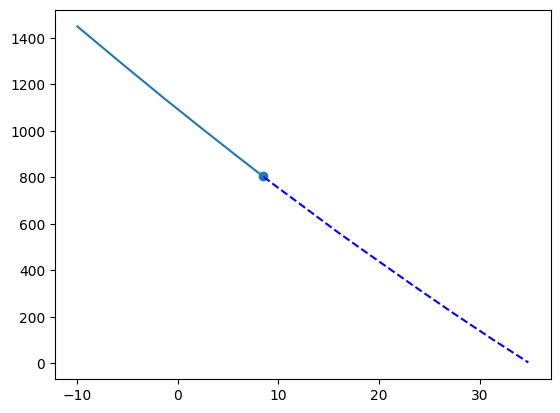

In [48]:
plt.plot(Temps_for_smaller,Wc_for_smaller)
plt.scatter(change[0],change[1])
plt.plot(Temps_for_bigger,Wc_for_bigger,linestyle='--',color='blue')

In [49]:
Wc_for_smaller[np.argmin(np.abs(Temps_for_smaller))]/1000

1.0950582886763973

In [50]:
print(np.min(Wc_for_bigger),np.min(Wc_for_smaller))

4.1470314338734955 808.0735195103299


In [51]:
# 7
def model7_1(Tc,Th,T2,T4,Qh):

    Tc += 273.15
    Th += 273.15
    T2 += 273.15
    T4 += 273.15

    P4_interp = interp1d(T,P)
    P4 = P4_interp(T4)

    h_interp = interp1d(T,hg)
    h2 = h_interp(T2)
    
    s_interp = interp1d(T,sg)
    s2 = s_interp(T2)
    s3 = s2
    #T_interp = interp1d(Tgs,sgs)
    #T3 = T_interp()

    h4_interp = interp1d(P,hf)
    h4 = h4_interp(P4)

    h1 = h4

    points = np.column_stack((Pgs, sgs))
    values = hgs
    h3 = griddata(points, values, (P4, s2), method='linear')

    qc = h2-h1
    qh = h3-h4

    mdotc = np.max([G*(Tc-T2)/qc,0])
    mdoth = np.max([G*(T4-Th)/qh,0])
    mmax = np.min([mdoth,mdotc])

    actual_m = Qh/qh

    ratio = mmax-actual_m

    Wc = actual_m*(h3-h2)
    COP = qh/(h3-h2)

    return Wc, ratio

In [ ]:
model7_1(5,22)

In [61]:

def model7_2(Tc,Th):
    Wcs = []
    
    Qh = (Th-Tc)/0.00147

    T2 = np.linspace(-20,Tc,200)
    T4 = np.linspace(Th,50,200)

    for i in range(len(T2)):
        print(i)

        for j in range(len(T4)):

            if T4[j] > T2[i]:
            
                Wc, ratio = model7_1(Tc,Th,T2[i],T4[j],Qh)
                print(j)
                if ratio > 0:
                    Wcs.append(Wc)
    return min(Wcs)

In [62]:
model7_2(5,22)


0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103


931.2790388006929

In [54]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# Fixed parameters
Tc = 5  # example
Th = 22  # example
Qh = (Th - Tc)/0.00147

# Define bounds for T2 and T4
space  = [
    Real(-20, 5, name='T2'),
    Real(22, 50, name='T4')
]

@use_named_args(space)
def objective(T2, T4):
    if T4 <= T2:
        return 1e6  # Physically invalid
    try:
        Wc, ratio = model7_1(Tc, Th, T2, T4, Qh)
        if np.isnan(Wc) or np.isinf(Wc) or ratio < 0:
            return 1e6  # Invalid result or constraint violation
        return float(Wc)
    except Exception:
        return 1e6



c:\Users\vadim\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [55]:
res = gp_minimize(objective, space, n_calls=10, random_state=0,acq_func='LCB',acq_func_kwargs={"kappa": 5})

print("Best T2:", res.x[0])
print("Best T4:", res.x[1])
print("Minimum Wc:", res.fun)


TypeError: gp_minimize() got an unexpected keyword argument 'acq_func_kwargs'

In [ ]:
res = gp_minimize(objective, space, n_calls=30, random_state=0,acq_func='LCB')

print("Best T2:", res.x[0])
print("Best T4:", res.x[1])
print("Minimum Wc:", res.fun)


Best T2: 0.8761616201594151
Best T4: 32.78085296304683
Minimum Wc: 1399.3775155936655
